# 1. Import Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV ,cross_val_score , cross_validate, train_test_split
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder , StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

# 2. Data Loading and Understanding

In [2]:
# read csv data to a pandas dataframe
df = pd.read_csv(r"F:\epsilon codes\projects\customer churn\dataset\Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
pd.set_option("display.max_columns",None)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# dropping customerID column as this is not required for modelling
df.drop(columns=["customerID"],inplace = True)

In [8]:
# printing the unique values in all the columns
numerical_columns = ["tenure","MonthlyCharges","TotalCharges"]

for col in df.columns:
    if col not in numerical_columns:
        print(col , df[col].unique())
        print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [9]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(22)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df[df["TotalCharges"] == " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [13]:
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"})

In [14]:
df["TotalCharges"] = df["TotalCharges"].astype("float",errors="ignore")

In [15]:
# checking the class distribution of target column
df["Churn"].value_counts()

Churn
No     5164
Yes    1857
Name: count, dtype: int64

**Insight:**
1. Customer ID removed as it is not required for modelling
2. No missing values in the dataset
3. Missing values in TotalCharges column were replaced with 0
4. Class imbalance identified in the target

# 3. Exploratory Data Analysis (EDA)

In [16]:
df.shape

(7021, 20)

In [17]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7021.000000,7021.000000,7021.000000,7021.000000
mean,0.162512,32.469449,64.851894,2286.765026
std,0.368947,24.534965,30.069001,2266.855057
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.750000,403.350000
50%,0.000000,29.000000,70.400000,1400.550000
75%,0.000000,55.000000,89.900000,3801.700000
max,1.000000,72.000000,118.750000,8684.800000


## Univariate analysis

### Numerical Features - Analysis

#### Understand distribution of the numerical features

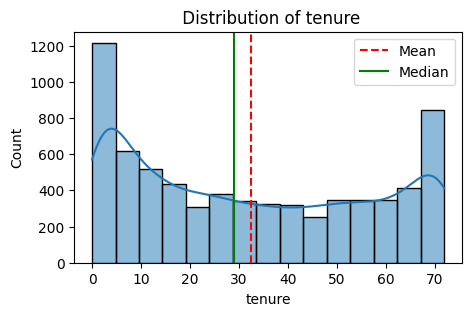

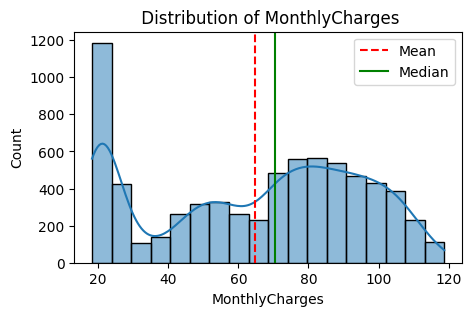

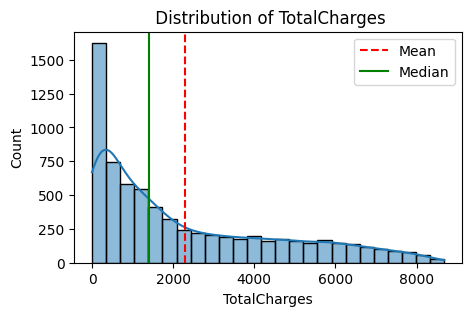

In [20]:
for column_name in ["tenure","MonthlyCharges","TotalCharges"]:
    plt.figure(figsize=(5,3))
    sns.histplot(data=df[column_name],kde=True)
    plt.title(f" Distribution of {column_name}")

    # calculate the mean and median values for the columns
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    # Add vertical lines for mean and median
    plt.axvline(col_mean, color="red",linestyle="--" ,label="Mean")
    plt.axvline(col_median, color="green",linestyle="-" ,label="Median")

    plt.legend()
    plt.show()

#### Box plot for numerical features

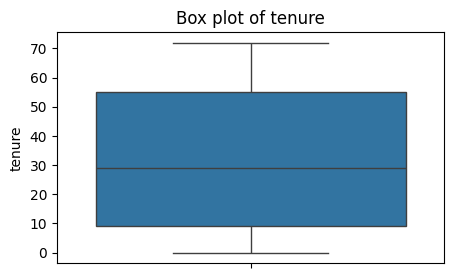

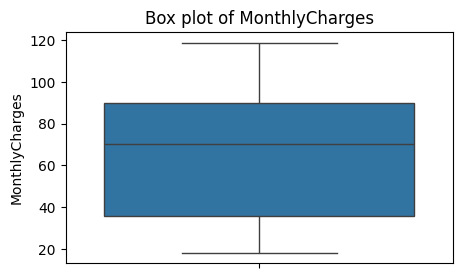

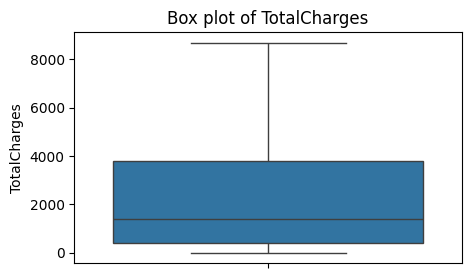

In [21]:
for column_name in ["tenure","MonthlyCharges","TotalCharges"]:
    plt.figure(figsize=(5,3))   
    sns.boxplot(df[column_name])
    plt.title(f"Box plot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

#### Correlation Heatmap for numerical columns

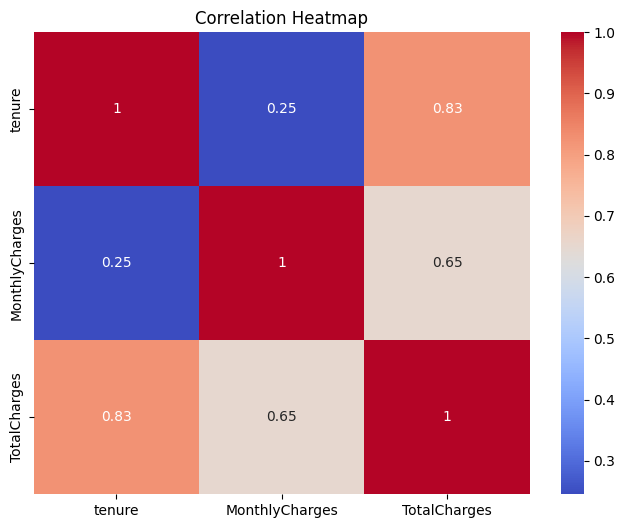

In [22]:
# Correlation matrix - heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Categorical Features - Analysis

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

#### Count plot for categorical columns 

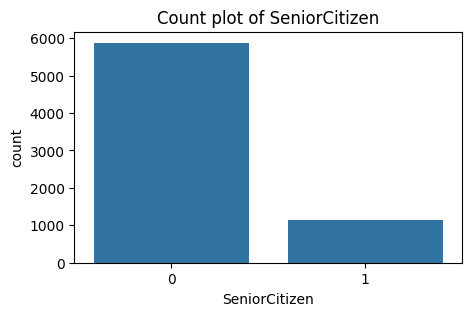

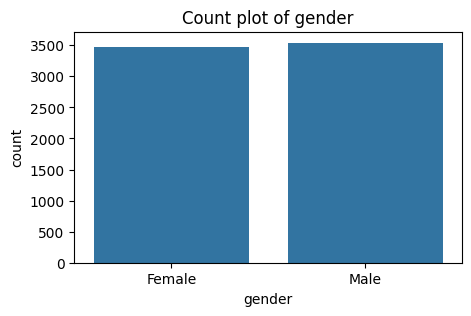

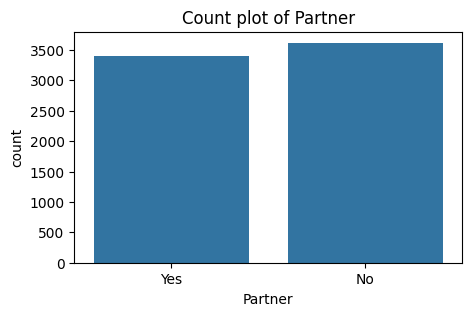

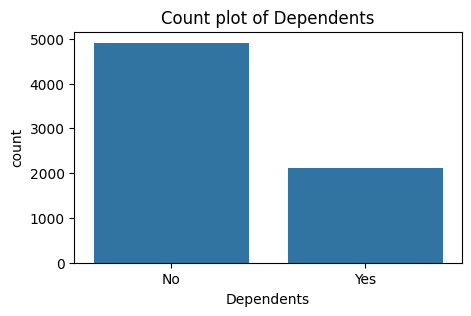

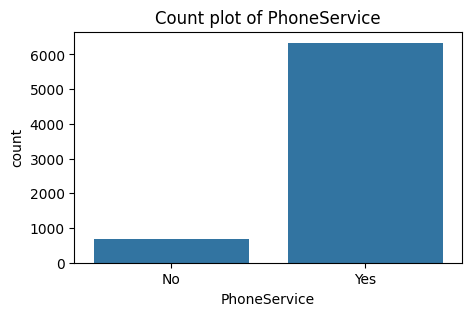

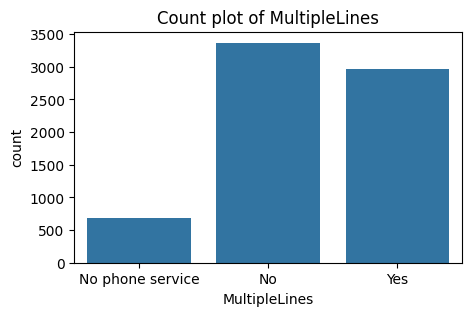

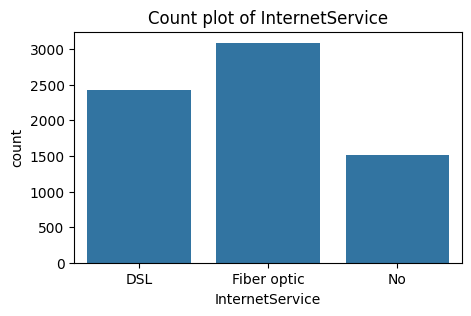

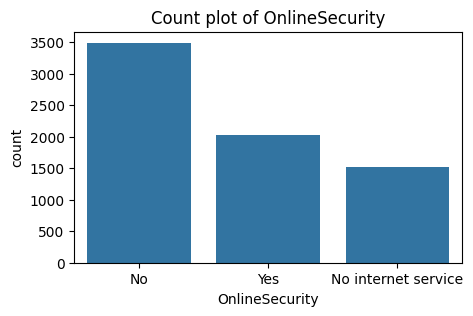

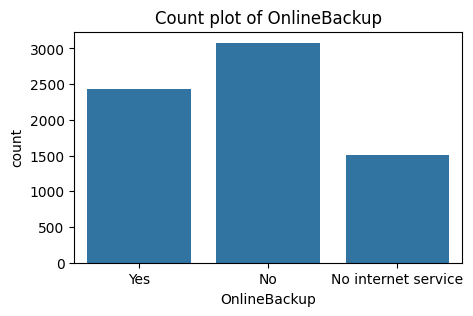

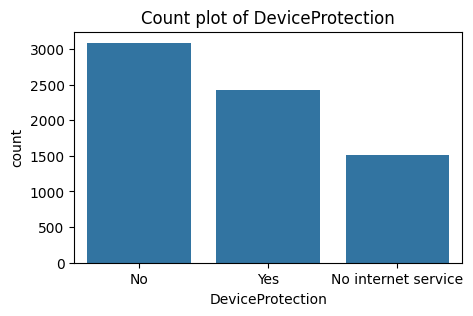

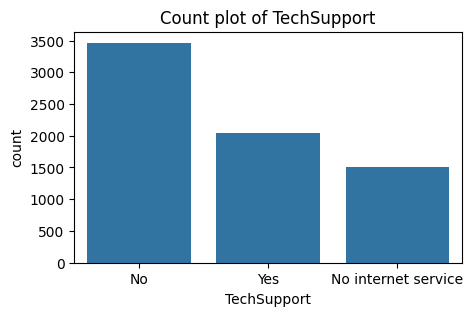

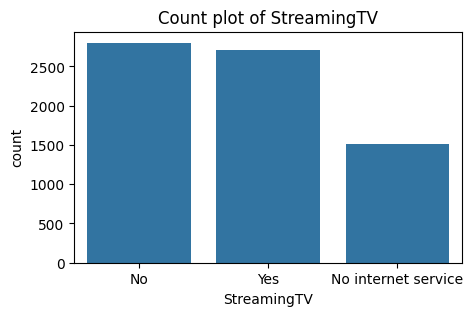

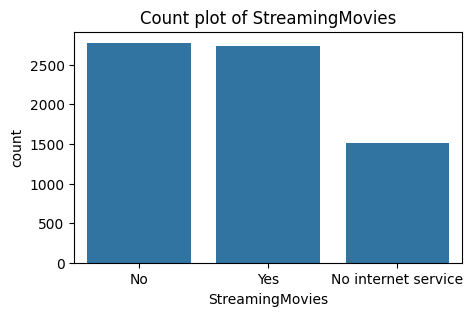

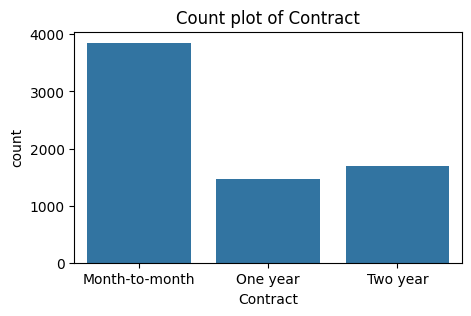

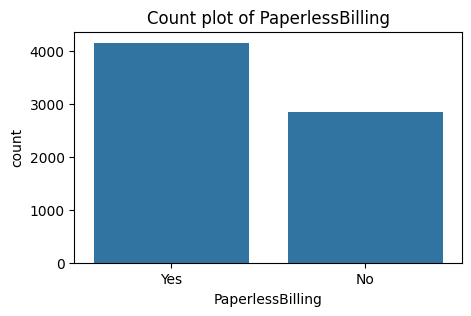

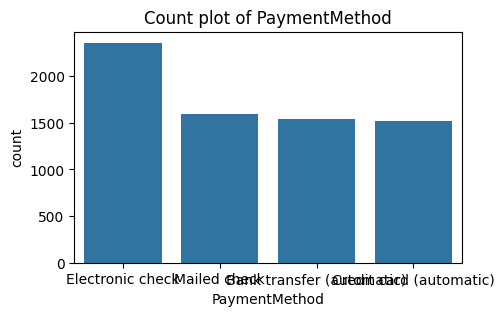

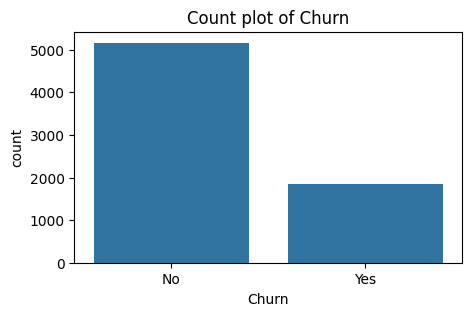

In [24]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Count plot of {col}")
    plt.show()

## Bivariate Analysis

### Numerical Features & Churn

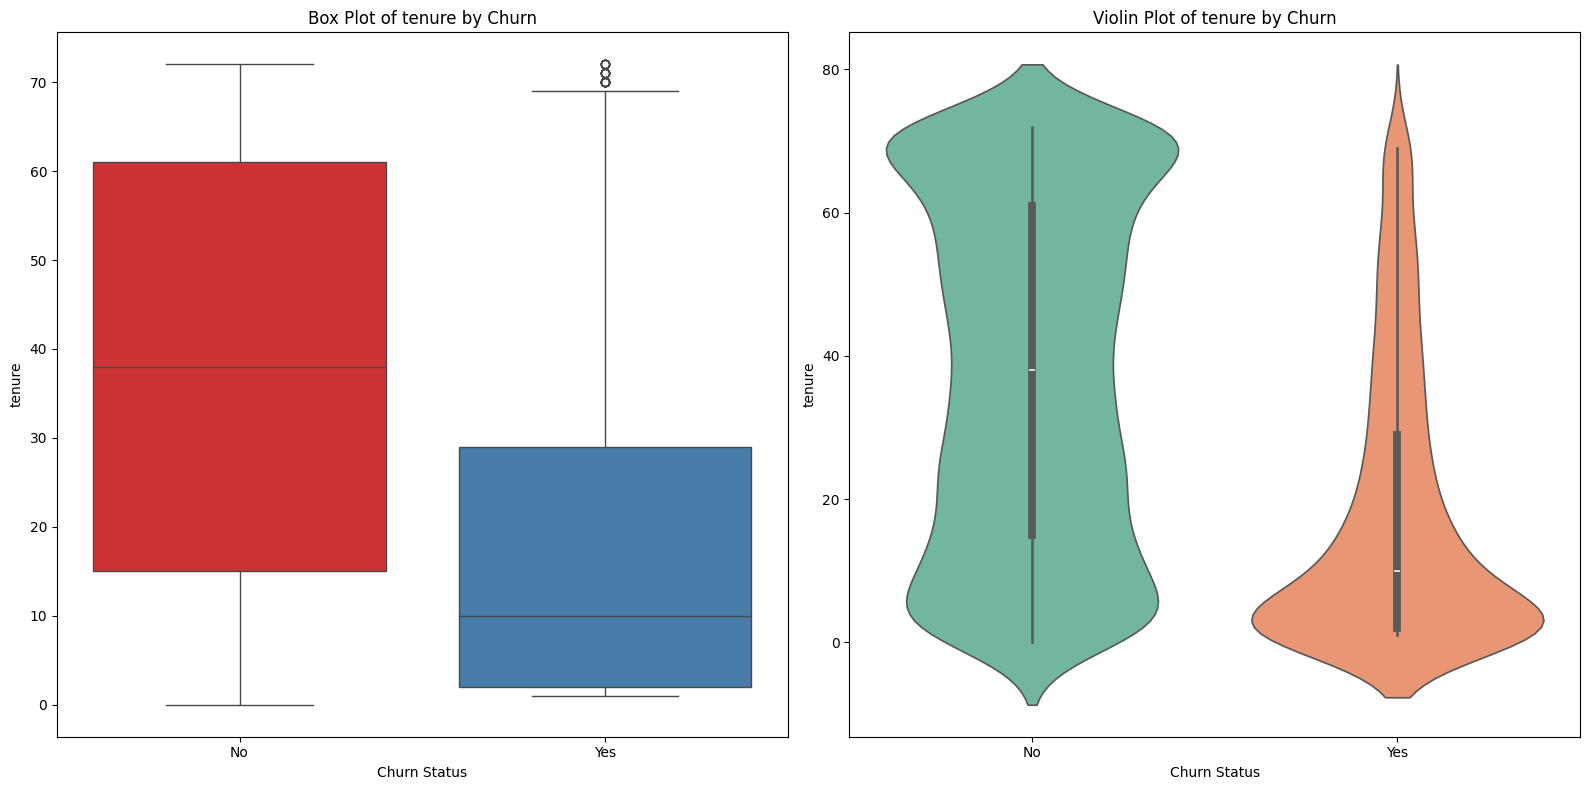

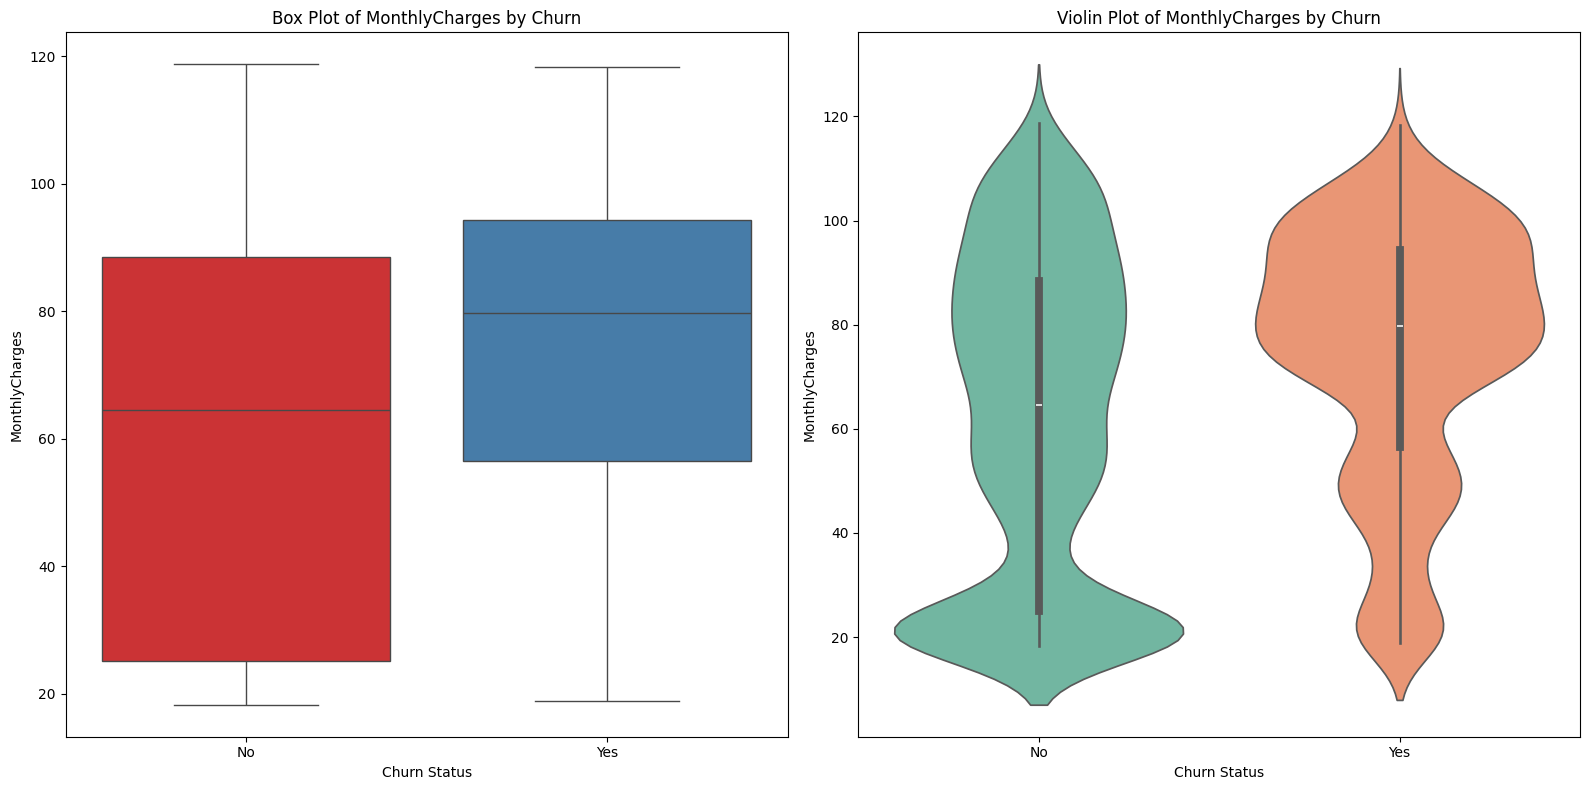

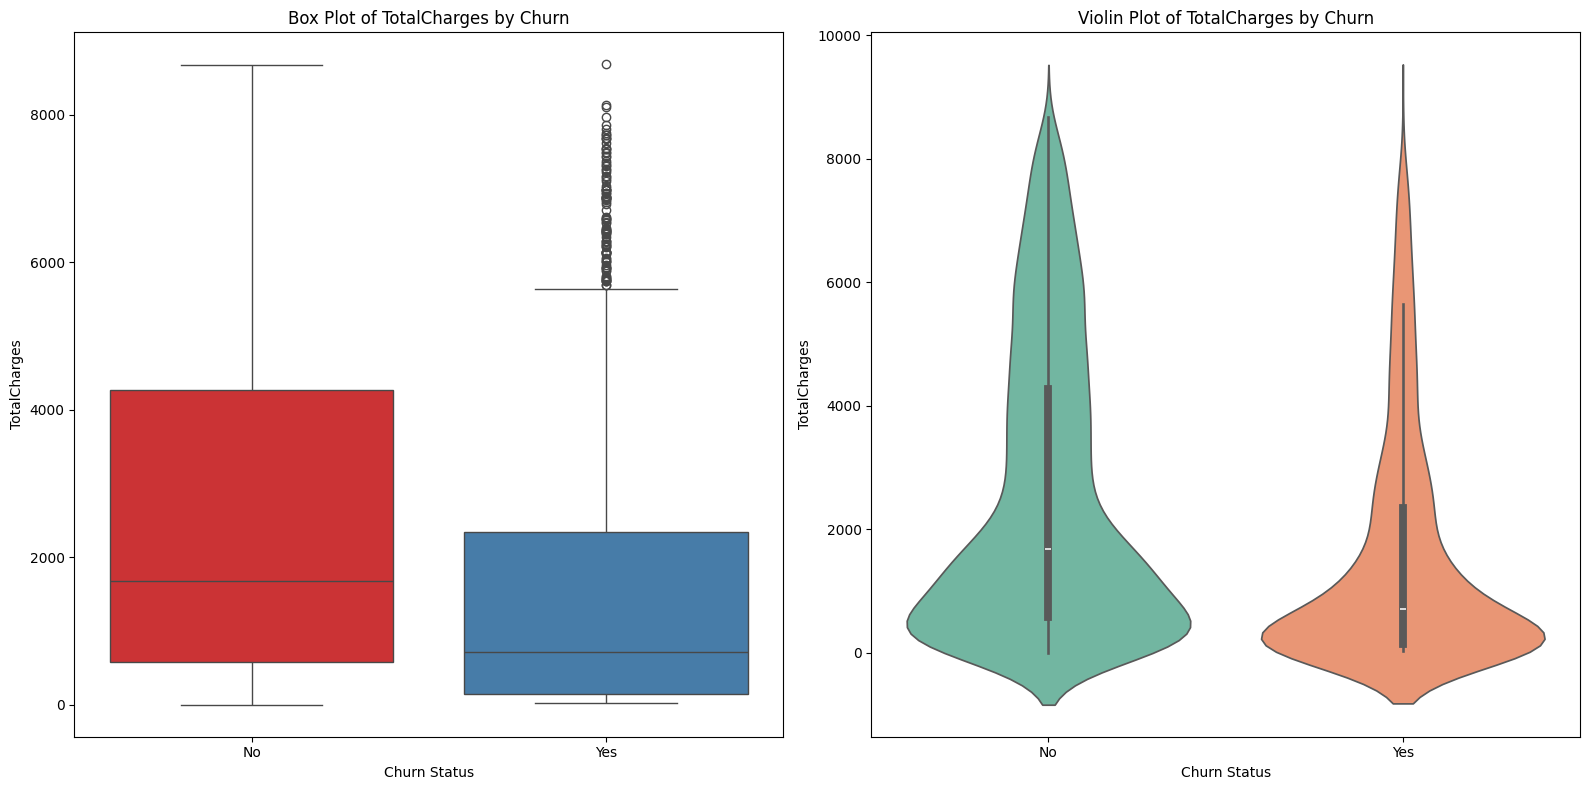

In [25]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    sns.boxplot(data=df, x="Churn", y=df[col], hue="Churn",palette="Set1", ax=axes[0])
    axes[0].set_title(f"Box Plot of {col} by Churn")
    axes[0].set_xlabel("Churn Status")
    axes[0].set_ylabel(f"{col}")

    sns.violinplot(data=df, x="Churn", y=df[col], hue="Churn",palette="Set2", ax=axes[1])
    axes[1].set_title(f"Violin Plot of {col} by Churn")
    axes[1].set_xlabel("Churn Status")
    axes[1].set_ylabel(f"{col}")

    plt.tight_layout()
    plt.show()

### Categorical Features & Churn

In [26]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


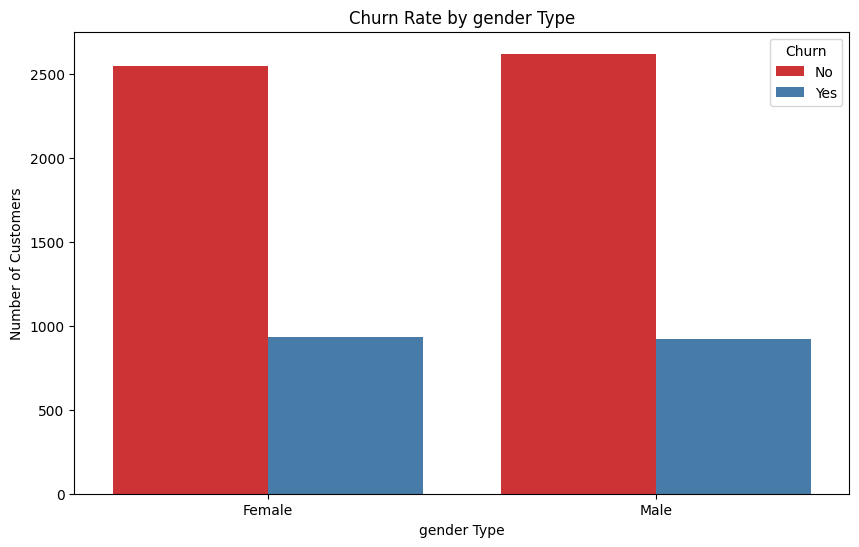

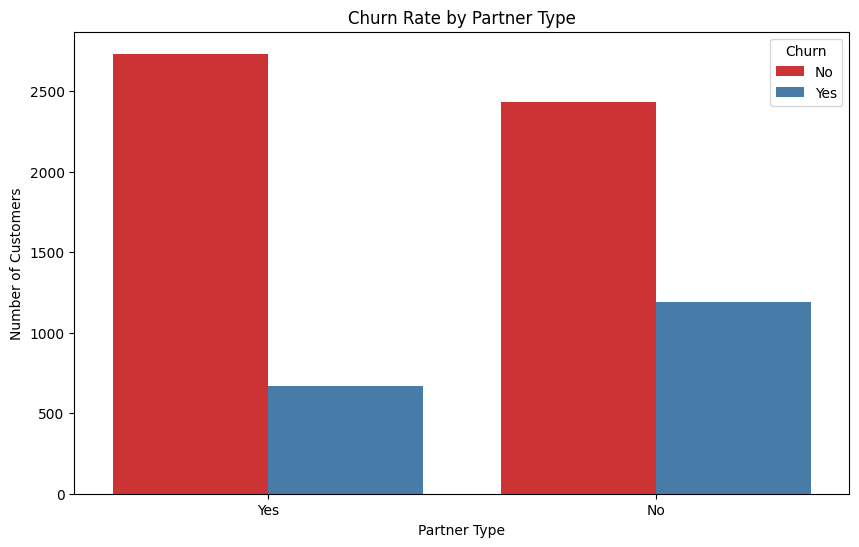

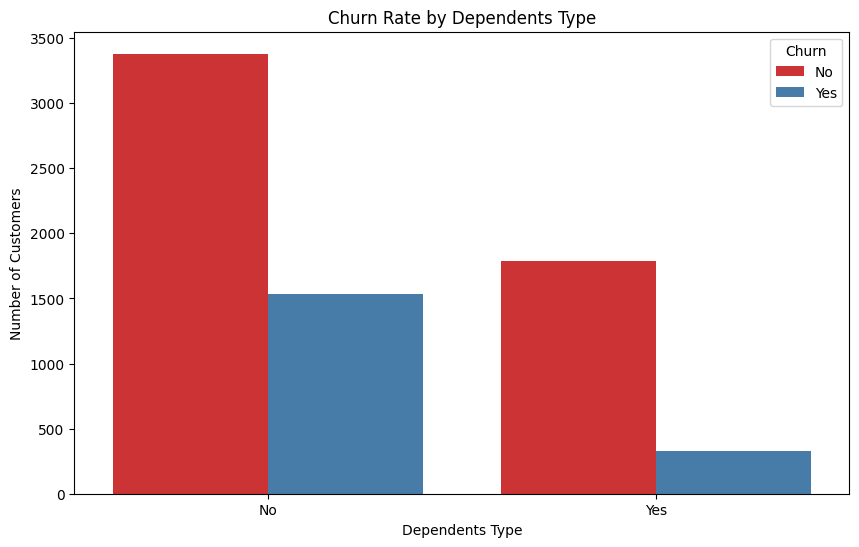

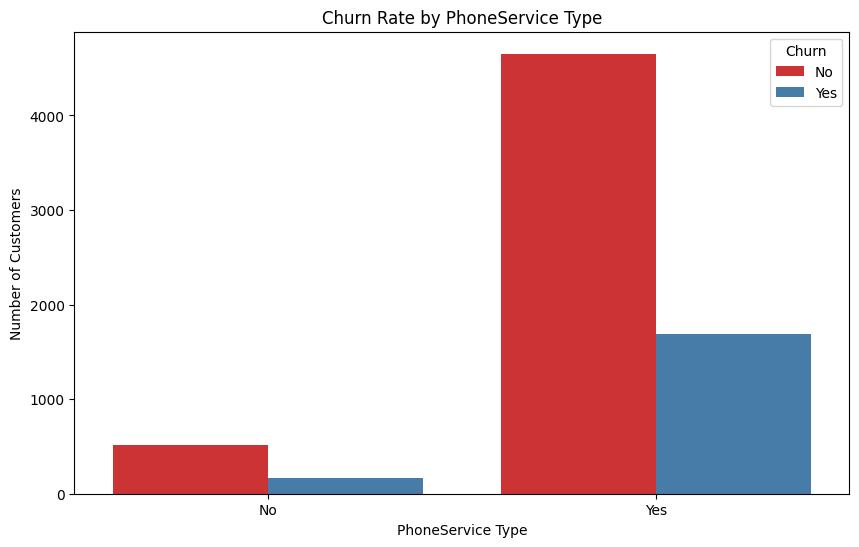

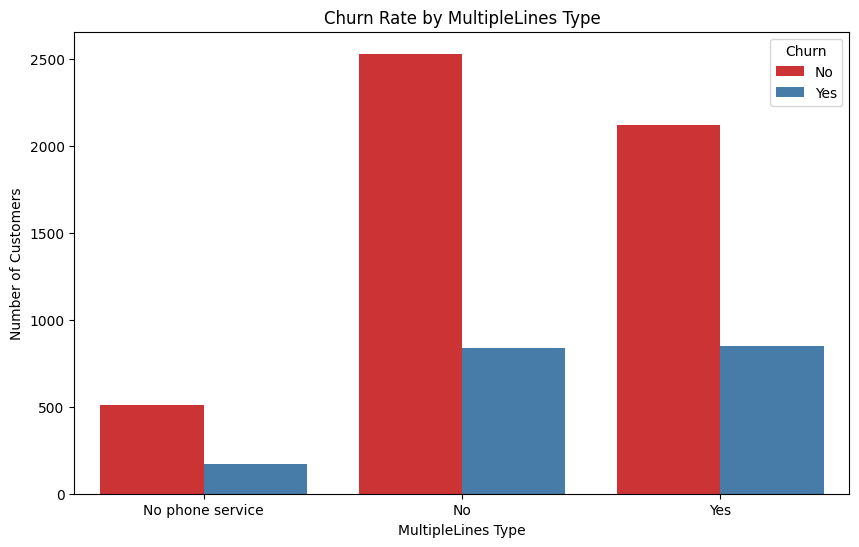

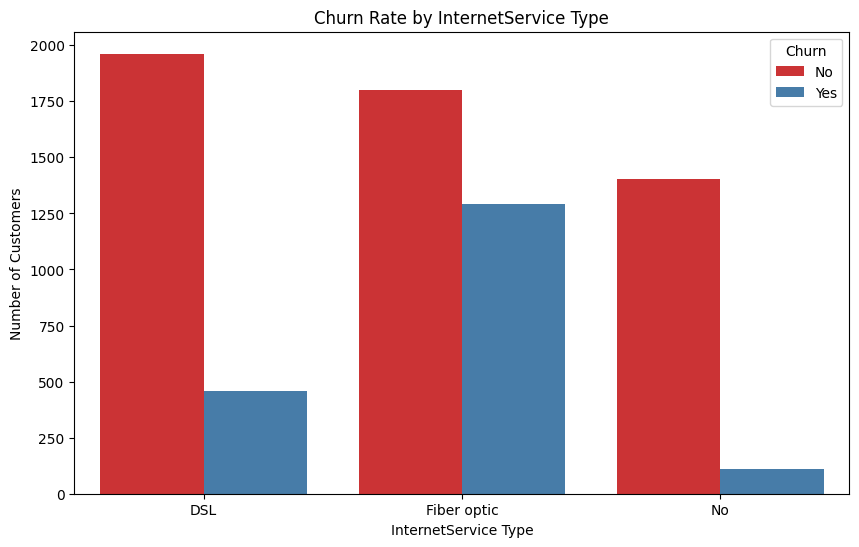

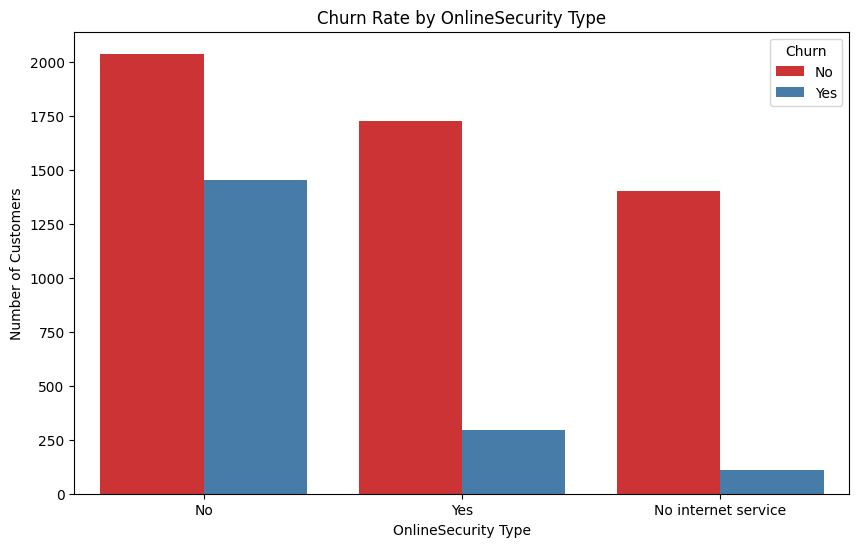

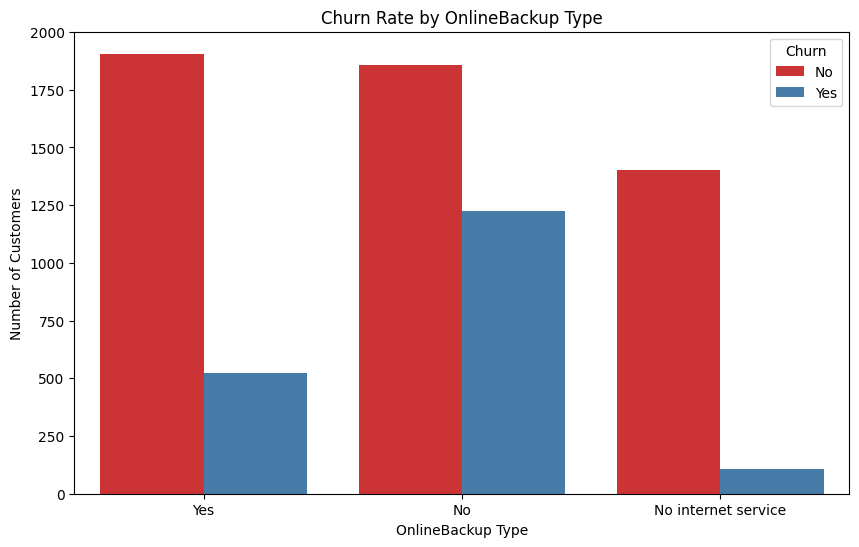

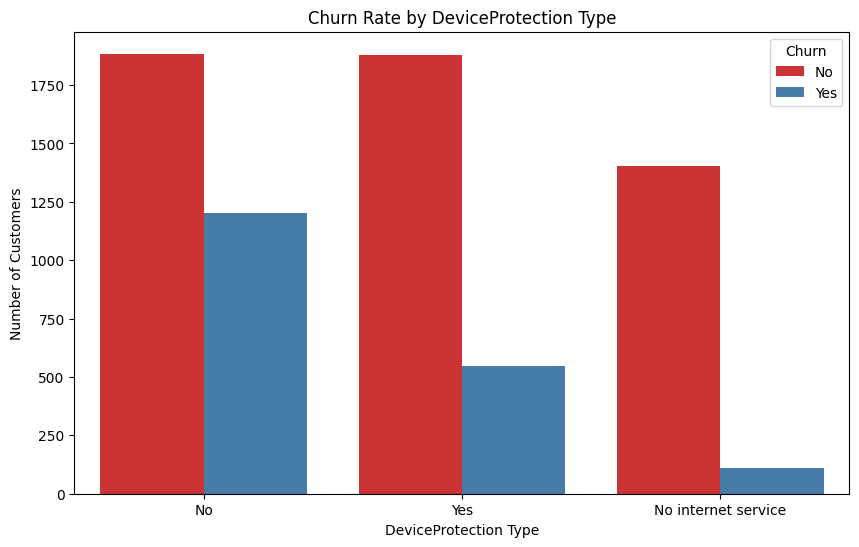

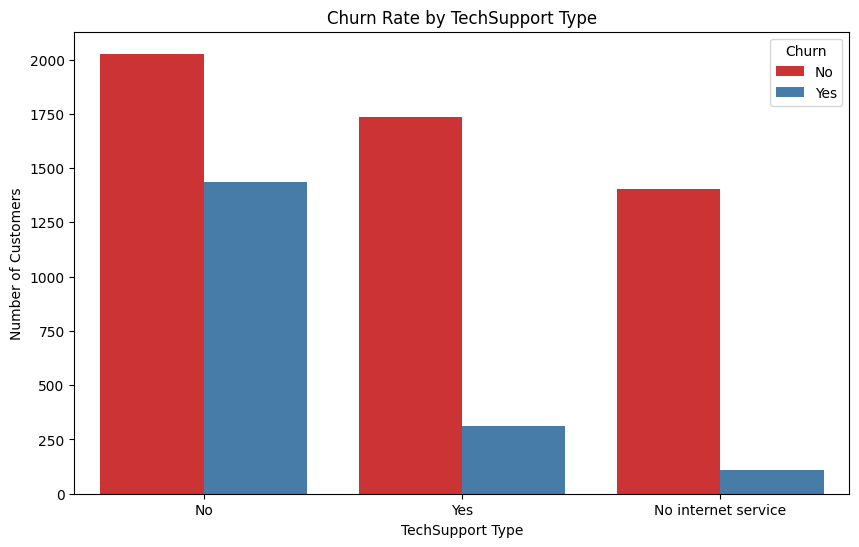

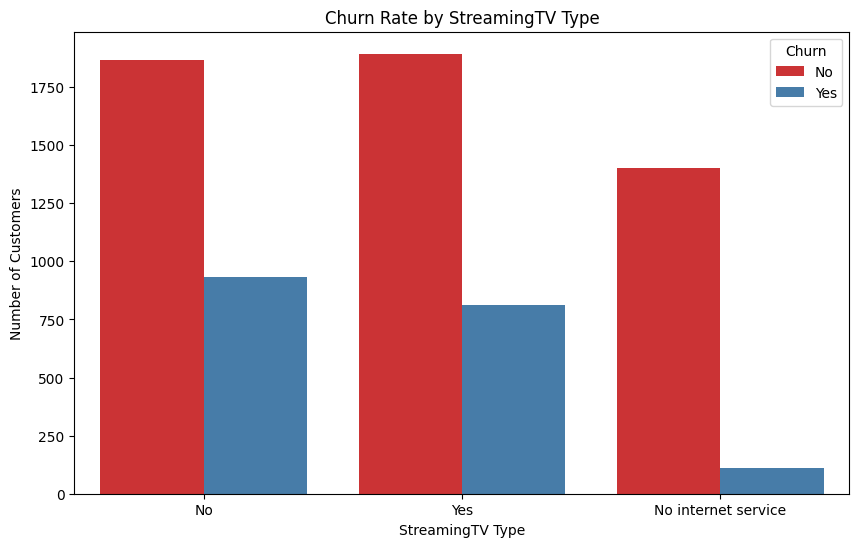

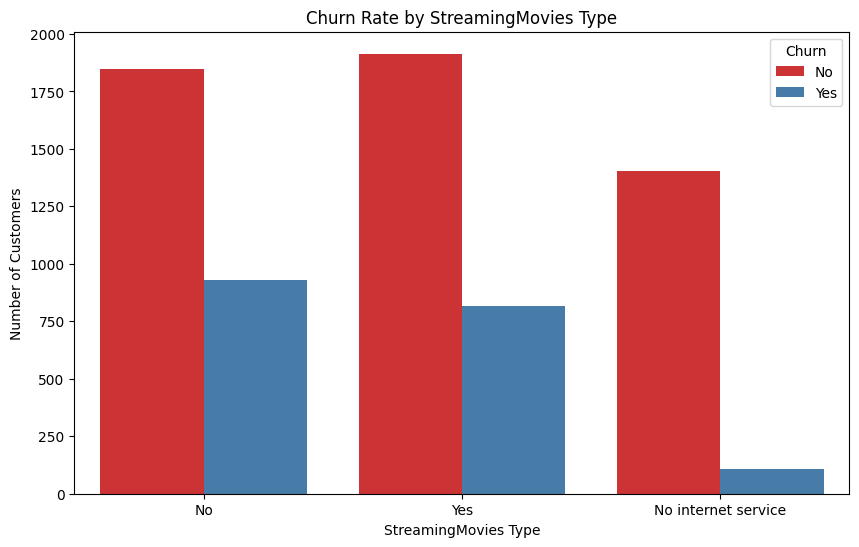

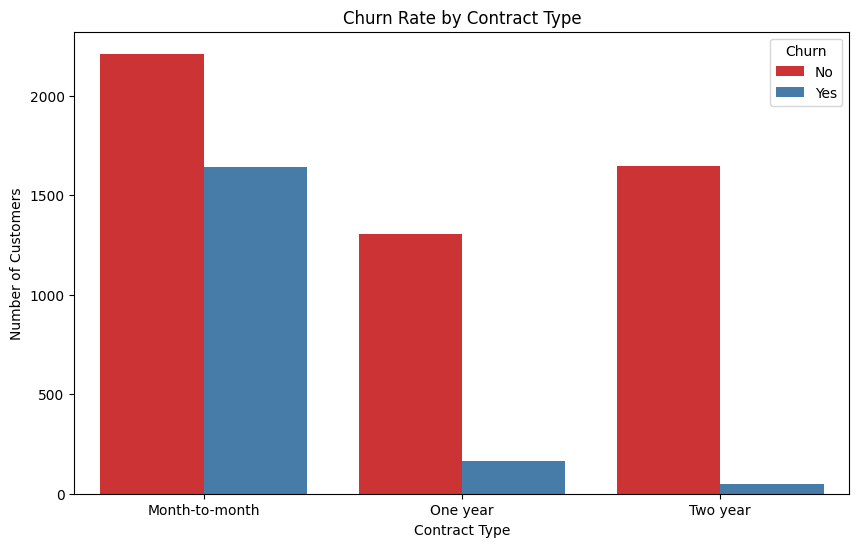

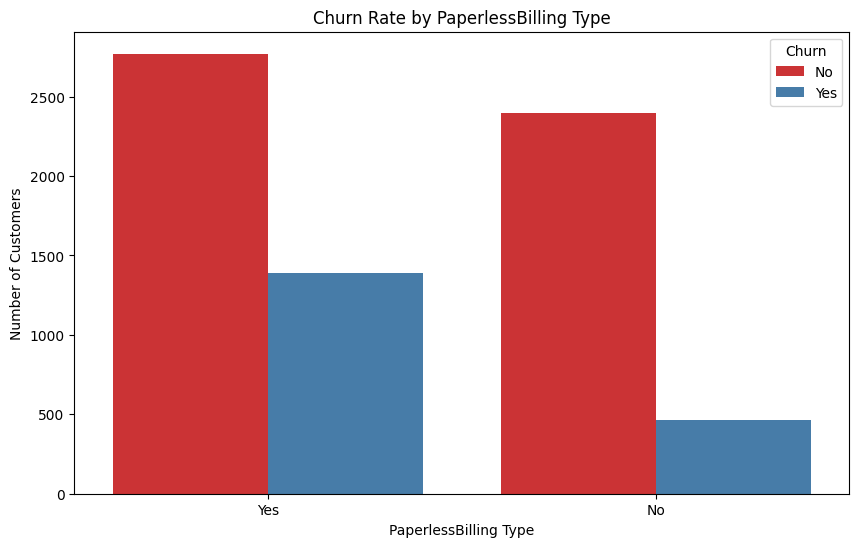

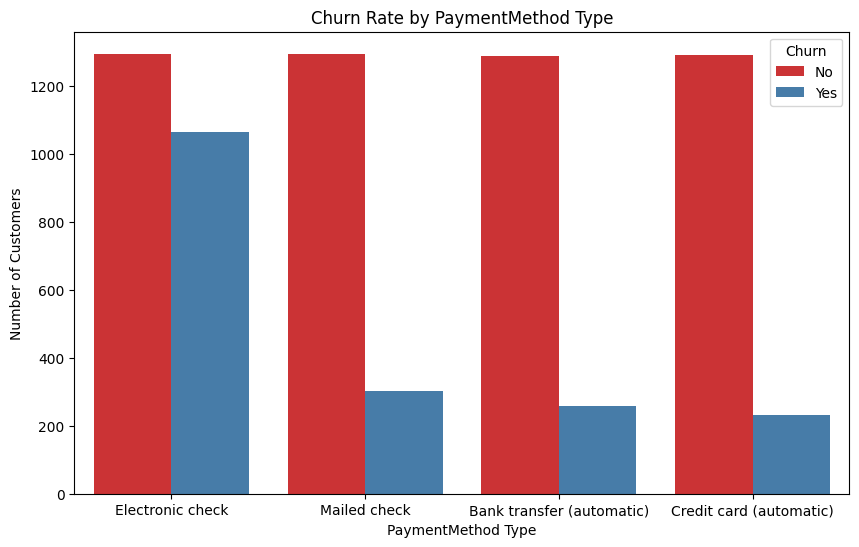

In [27]:
categorical_columns = df.select_dtypes(include="O").columns.tolist()
if "Churn" in categorical_columns:
    categorical_columns.remove("Churn")
    
for col in categorical_columns:
    plt.figure(figsize=(10,6))
    sns.countplot(data=df , x=col, hue="Churn", palette="Set1")
    plt.title(f"Churn Rate by {col} Type")
    plt.xlabel(f"{col} Type")
    plt.ylabel(f"Number of Customers")
    plt.legend(title="Churn")
    plt.show()

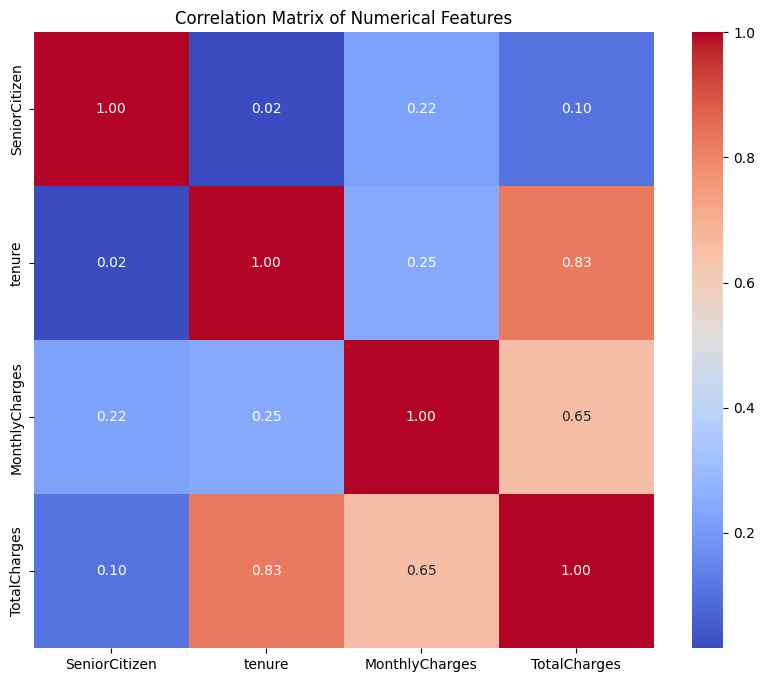

In [28]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## 4. Data Preprocessing

#### Training and test data split

In [29]:
# spliting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [30]:
# split training and test data
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Encoding of target column

In [31]:
target_map = {"No": 0, "Yes": 1}
y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

#### Encoding of categorical features

In [32]:
# identifying columns with object data type
object_columns = X_train.select_dtypes(include="object").columns.tolist()

In [33]:
# Column encoding
if "Contract" in object_columns:
    object_columns.remove("Contract")

onehot = OneHotEncoder(drop="first",sparse_output=False)

X_train_encoded = onehot.fit_transform(X_train[object_columns])
X_test_encoded = onehot.transform(X_test[object_columns])

train_encoded_df = pd.DataFrame(data=X_train_encoded, columns=onehot.get_feature_names_out(object_columns))
test_encoded_df = pd.DataFrame(data=X_test_encoded, columns=onehot.get_feature_names_out(object_columns))

contract_order = [["Month-to-month", "One year", "Two year"]]
ordinal = OrdinalEncoder(categories=contract_order)

X_train["Contract"] = ordinal.fit_transform(X_train[["Contract"]])
X_test["Contract"] = ordinal.transform(X_test[["Contract"]])

X_train = X_train.drop(columns=object_columns).reset_index(drop=True)
X_train = pd.concat([X_train, train_encoded_df], axis=1)

X_test = X_test.drop(columns=object_columns).reset_index(drop=True)
X_test = pd.concat([X_test, test_encoded_df], axis=1)

#### Scaling of numerical features

In [34]:
# identifying numerical columns
numerical_cols = ["tenure","MonthlyCharges","TotalCharges"]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [35]:
X_train.head()

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.162519,0.0,0.474849,-0.868118,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1,1,0.026315,0.0,0.630667,0.191249,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0,-1.162519,0.0,-1.474544,-0.974494,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0,-0.957548,1.0,-1.489463,-0.935525,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0,-0.137662,2.0,-1.283915,-0.702394,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## 5. Model Training

#### Training with default hyperparameters

In [36]:
# dictionary of models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [39]:
# perform 5-fold cross validation for each model 
for model_name , model in models.items():
    cv_model_score = cross_validate(model, X_train,y_train,cv=5,scoring="accuracy",return_train_score=True)
    print(f"Train score of {model_name } : {np.mean(cv_model_score['train_score']):.2f}")
    print(f"Test accuracy of {model_name} : {np.mean(cv_model_score['test_score']):.2f}")
    print("-"*60)

Train score of Logistic Regression : 0.81
Test accuracy of Logistic Regression : 0.81
------------------------------------------------------------
Train score of Decision Tree : 1.00
Test accuracy of Decision Tree : 0.73
------------------------------------------------------------
Train score of Random Forest : 1.00
Test accuracy of Random Forest : 0.79
------------------------------------------------------------
Train score of XGBoost : 0.95
Test accuracy of XGBoost : 0.79
------------------------------------------------------------


#### Random Forest gives the hightest accuracy compared to other models with default parameters

### 🧪 Experiment 1: Baseline Random Forest Model (Without Handling Imbalance)
In this first experiment, we will train a standard `RandomForestClassifier` using its default parameters without applying any techniques to handle the class imbalance. This will serve as our benchmark (Baseline) to understand how the imbalance affects the model's ability to catch churning customers (Class 1).

 --- Baseline Model Performance --- 
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1053
           1       0.59      0.48      0.53       352

    accuracy                           0.79      1405
   macro avg       0.71      0.68      0.70      1405
weighted avg       0.77      0.79      0.78      1405



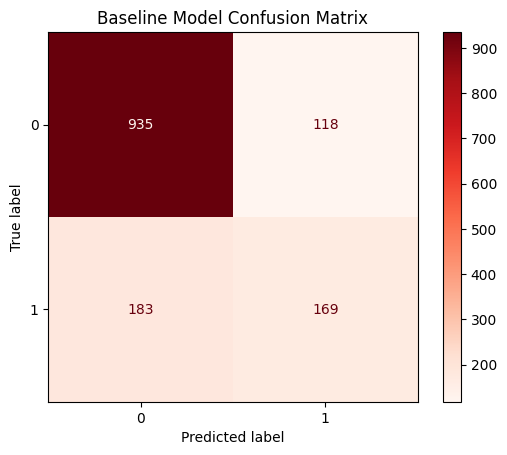

In [41]:
baseline_rfc = RandomForestClassifier(random_state=42)
baseline_rfc.fit(X_train, y_train)

y_pred_baseline = baseline_rfc.predict(X_test)

print(" --- Baseline Model Performance --- ")
print(classification_report(y_test, y_pred_baseline))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_baseline, cmap='Reds')
plt.title("Baseline Model Confusion Matrix")
plt.show()

### 🧪 Experiment 2: Handling Imbalance via Data Level (Using SMOTE)
To address the class imbalance, we will use the **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE works by generating synthetic (artificial) examples of the minority class (Class 1) to balance the dataset. 

*Note: We only apply SMOTE on the training set (`X_train`, `y_train`) to avoid any data leakage into the test set.*

 --- SMOTE Model Performance --- 
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1053
           1       0.55      0.58      0.57       352

    accuracy                           0.78      1405
   macro avg       0.70      0.71      0.71      1405
weighted avg       0.78      0.78      0.78      1405



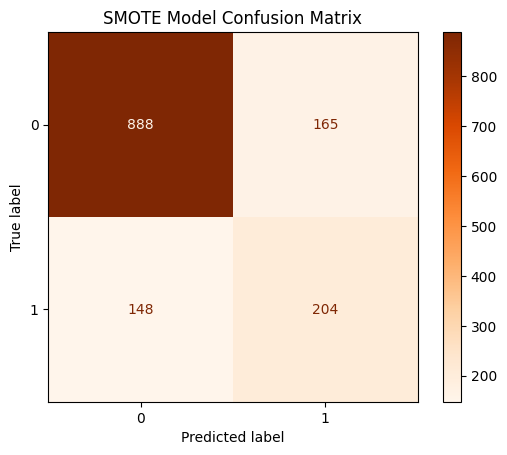

In [42]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote_rfc = RandomForestClassifier(random_state=42)
smote_rfc.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_rfc.predict(X_test)

print(" --- SMOTE Model Performance --- ")
print(classification_report(y_test, y_pred_smote))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, cmap='Oranges')
plt.title("SMOTE Model Confusion Matrix")
plt.show()

### 🧪 Experiment 3: Algorithmic Approach & Hyperparameter Tuning (The Winning Model)
In this final experiment, instead of changing the data, we will guide the algorithm itself by penalizing mistakes on the minority class using `class_weight='balanced'`. Furthermore, we performed a `GridSearchCV` optimized for the **F1-Score** to find the optimal combination of tree depth, split sizes, and estimators.

This approach ensures the model remains robust and generalizes well to unseen real-world test data.

In [43]:
param_rfc = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 17, None],
    'min_samples_split': [10, 15, 18],
    'min_samples_leaf': [4, 6, 8]
}

rfc = RandomForestClassifier(class_weight="balanced", random_state=42)
grid = GridSearchCV(estimator=rfc, param_grid=param_rfc, cv=5, scoring='f1', n_jobs=-1)

grid.fit(X_train, y_train)

print(" Best Parameters Found:", grid.best_params_)
print(" Best F1-Score Achieved:", grid.best_score_)

 Best Parameters Found: {'max_depth': 17, 'min_samples_leaf': 6, 'min_samples_split': 18, 'n_estimators': 150}
 Best F1-Score Achieved: 0.6459683368381023


 --- Final Optimized Model Performance --- 
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1053
           1       0.53      0.74      0.62       352

    accuracy                           0.77      1405
   macro avg       0.71      0.76      0.73      1405
weighted avg       0.81      0.77      0.78      1405



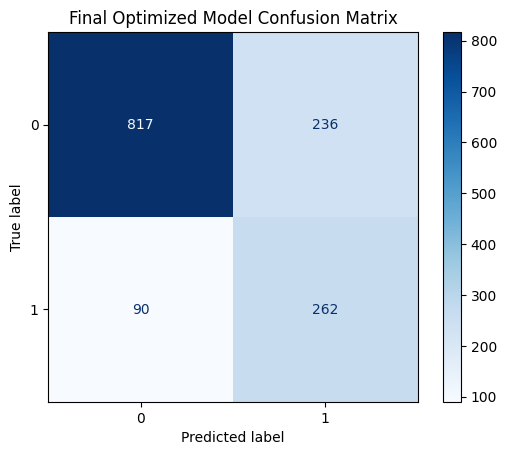

In [44]:
y_pred_final = grid.predict(X_test)

print(" --- Final Optimized Model Performance --- ")
print(classification_report(y_test, y_pred_final))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='Blues')
plt.title("Final Optimized Model Confusion Matrix")
plt.show()

## 6. Business Insights & Model Deployment
Now that we have our champion tuned model, let's look under the hood to see which features (factors) are driving customer churn the most. This provides actionable insights for the marketing and retention teams to take proactive steps. Finally, we will save the model for production.

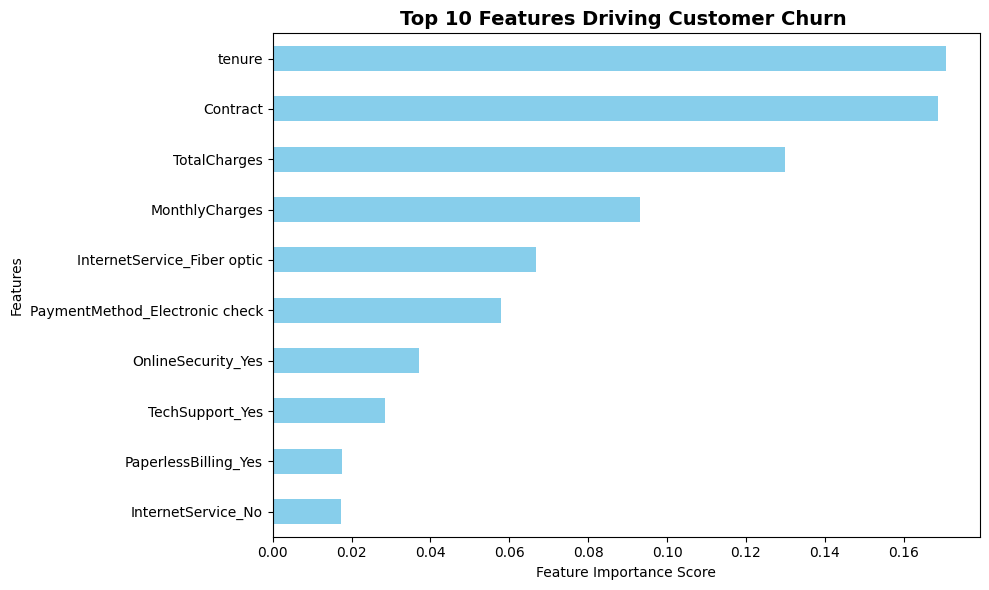

In [87]:
best_model = grid.best_estimator_
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Features Driving Customer Churn ", fontsize=14, fontweight='bold')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

## 5. Model Saving

In [88]:
joblib.dump(best_model, 'customer_churn_model.pkl')

['customer_churn_model.pkl']